# nodetool tablestats: JMX vs CQL protocol

Run `./bench_tablestats.py` against a local node first. It writes `tablestats_bench.csv` (median wall time in ms per protocol at each table count).

CQL run: `./nodetool -Dcassandra.cli.execution.protocol=cql tablestats`  
JMX run: `./nodetool tablestats`

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tablestats_bench.csv")
df

,tables,jmx,cql,speedup
0,0,6206.021083,1387.079541,4.474164
1,20,6378.518750,1434.782708,4.445634
2,40,6633.746875,1358.168417,4.884333
3,60,6637.795833,1364.641334,4.864132
4,80,6726.019166,1298.212083,5.180986
5,100,6810.154833,1288.643250,5.284748
6,120,6957.617375,1324.990333,5.251070
7,140,7107.849375,1364.460166,5.209276
8,160,7248.531583,1319.403958,5.493793
9,180,7301.255500,1365.996458,5.345003


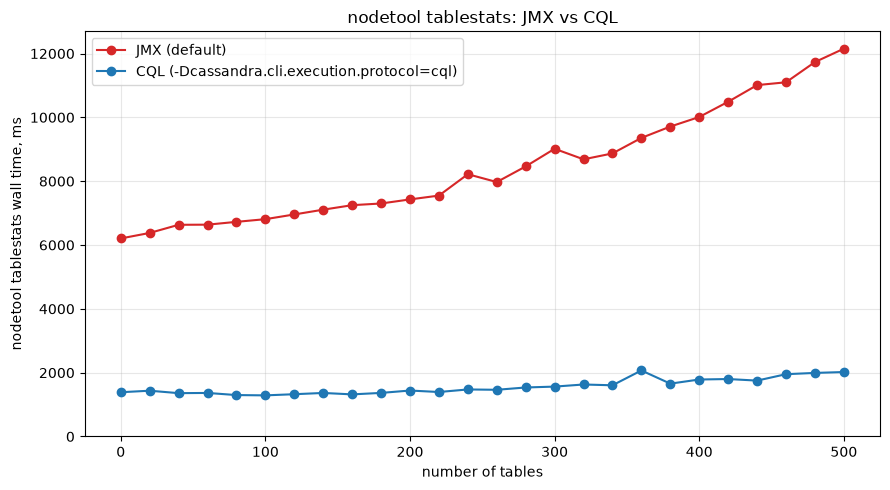

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tablestats_bench.csv")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df.tables, df.jmx, marker="o", color="#d62728", label="JMX (default)")
ax.plot(df.tables, df.cql, marker="o", color="#1f77b4", label="CQL (-Dcassandra.cli.execution.protocol=cql)")
ax.set_xlabel("number of tables")
ax.set_ylabel("nodetool tablestats wall time, ms")
ax.set_title("nodetool tablestats: JMX vs CQL")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("tablestats_bench.png", dpi=150)
plt.show()

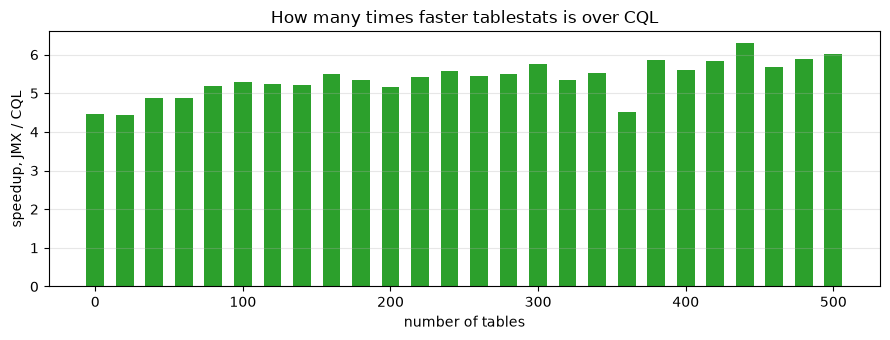

In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tablestats_bench.csv")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(df.tables, df.speedup, width=df.tables.diff().median() * 0.6, color="#2ca02c")
ax.set_xlabel("number of tables")
ax.set_ylabel("speedup, JMX / CQL")
ax.set_title("How many times faster tablestats is over CQL")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tablestats_bench.csv")
import numpy as np

# per-table marginal cost of each protocol (slope of a linear fit, ms per table)
for p in ("jmx", "cql"):
    slope, intercept = np.polyfit(df.tables, df[p], 1)
    print(f"{p}: {slope:.2f} ms/table, {intercept:.0f} ms fixed cost")

jmx: 11.21 ms/table, 5650 ms fixed cost
cql: 1.40 ms/table, 1213 ms fixed cost
